<a href="https://colab.research.google.com/github/abubakar020-git/COEN807/blob/main/Studentperformance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd

df = pd.read_csv('/content/student_performance.csv')
display(df.head())

,Name,Age,Gender,Major,Living_Area,Parent_Education,Scholarship_Status,Part_Time_Job,Extracurricular_Activities,Internet_Access,...,Sleep_Hours_Per_Day,Attendance_Rate,Stress_Level,Exam_Proximity,Math_Score,Science_Score,Language_Score,History_Score,Average_Score,Grade
0,Linda Johnson,24,Female,Arts,Rural,Bachelor,No,No,No,Yes,...,6.69,77.3,3.6,No,52,43,69,66,58,C
1,Thomas Thomas,21,Male,Arts,Suburban,Master,No,No,No,Yes,...,7.34,59.7,7.3,Yes,59,64,74,68,66,C
2,Joseph Rodriguez,23,Male,STEM,Suburban,High School,Yes,No,No,Yes,...,6.78,56.0,2.9,No,81,72,67,69,72,B
3,Michael Wright,25,Male,STEM,Rural,High School,No,No,No,Yes,...,9.59,84.9,3.2,No,63,72,55,58,62,C
4,Jennifer Nguyen,25,Female,Arts,Urban,Bachelor,Yes,No,No,Yes,...,7.04,98.2,4.6,Yes,69,76,90,86,80,B


In [11]:
# Display basic information about the dataset
display(df.info())

# Display descriptive statistics for numerical columns
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Name                        1000 non-null   object 
 1   Age                         1000 non-null   int64  
 2   Gender                      1000 non-null   object 
 3   Major                       1000 non-null   object 
 4   Living_Area                 1000 non-null   object 
 5   Parent_Education            1000 non-null   object 
 6   Scholarship_Status          1000 non-null   object 
 7   Part_Time_Job               1000 non-null   object 
 8   Extracurricular_Activities  1000 non-null   object 
 9   Internet_Access             1000 non-null   object 
 10  Study_Hours_Per_Day         1000 non-null   float64
 11  Sleep_Hours_Per_Day         1000 non-null   float64
 12  Attendance_Rate             1000 non-null   float64
 13  Stress_Level                1000 n

None

,Age,Study_Hours_Per_Day,Sleep_Hours_Per_Day,Attendance_Rate,Stress_Level,Math_Score,Science_Score,Language_Score,History_Score,Average_Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000,1000.000000,1000.000000
mean,21.453000,4.286350,7.048220,78.418000,4.060500,70.8390,69.789000,72.719000,69.482000,70.831000
std,2.293698,2.621616,1.242238,13.599243,1.648164,12.8598,12.231929,12.485188,12.345934,10.256004
min,18.000000,0.500000,2.500000,40.000000,1.000000,25.0000,28.000000,29.000000,26.000000,37.000000
25%,19.000000,2.387500,6.210000,69.275000,2.800000,62.0000,62.000000,64.000000,61.000000,64.000000
50%,21.000000,3.805000,7.080000,80.950000,3.900000,71.0000,70.000000,73.000000,69.000000,71.000000
75%,23.000000,5.815000,7.900000,89.100000,5.300000,80.0000,78.000000,81.000000,77.000000,78.000000
max,25.000000,15.500000,11.000000,99.800000,9.400000,100.0000,100.000000,100.000000,100.000000,97.000000


In [12]:
# Check for missing values
missing_values = df.isnull().sum()
print("\nMissing values in each column:")
display(missing_values[missing_values > 0])


Missing values in each column:


,0


In [13]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_rows}")

# If duplicates exist, remove them
if duplicate_rows > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")


Number of duplicate rows: 0


### Identify Target Variable and Features

In [14]:
print("Columns and their data types:")
display(df.dtypes)

# Based on the problem statement (predict student performance: Pass/Fail),
# we will use 'Average_Score' to define the target variable.
# Let's assume an 'Average_Score' of 50 or more is a 'Pass'.
df['passed'] = df['Average_Score'].apply(lambda x: 1 if x >= 50 else 0)

# Drop columns that would cause data leakage or are irrelevant for prediction:
# - 'Name' is an identifier.
# - 'Math_Score', 'Science_Score', 'Language_Score', 'History_Score', 'Average_Score' are source scores for 'passed'.
# - 'Grade' is also a derived score and not the direct target in binary form.
df = df.drop(columns=['Name', 'Math_Score', 'Science_Score', 'Language_Score', 'History_Score', 'Average_Score', 'Grade'])

print("\nUpdated DataFrame after creating 'passed' target variable and dropping score-related and identifier columns:")
display(df.head())

Columns and their data types:


,0
Name,object
Age,int64
Gender,object
Major,object
Living_Area,object
Parent_Education,object
Scholarship_Status,object
Part_Time_Job,object
Extracurricular_Activities,object
Internet_Access,object



Updated DataFrame after creating 'passed' target variable and dropping score-related and identifier columns:


,Age,Gender,Major,Living_Area,Parent_Education,Scholarship_Status,Part_Time_Job,Extracurricular_Activities,Internet_Access,Study_Hours_Per_Day,Sleep_Hours_Per_Day,Attendance_Rate,Stress_Level,Exam_Proximity,passed
0,24,Female,Arts,Rural,Bachelor,No,No,No,Yes,1.24,6.69,77.3,3.6,No,1
1,21,Male,Arts,Suburban,Master,No,No,No,Yes,3.67,7.34,59.7,7.3,Yes,1
2,23,Male,STEM,Suburban,High School,Yes,No,No,Yes,5.31,6.78,56.0,2.9,No,1
3,25,Male,STEM,Rural,High School,No,No,No,Yes,2.70,9.59,84.9,3.2,No,1
4,25,Female,Arts,Urban,Bachelor,Yes,No,No,Yes,3.59,7.04,98.2,4.6,Yes,1


### Categorical Feature Encoding

In [15]:
# Identify categorical columns (object type)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Identify numerical columns that should not be treated as categorical by default
# These are continuous or truly numerical features.
numerical_cols_to_exclude_from_nunique_check = ['Age', 'Study_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Attendance_Rate', 'Stress_Level']

# Also consider some numerical columns that might be categorical if they have few unique values
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    if col not in numerical_cols_to_exclude_from_nunique_check and col != 'passed':
        if df[col].nunique() < 10:
            categorical_cols.append(col)

# Convert to pd.Index for consistency with previous behavior if needed, but list is fine for get_dummies
categorical_cols = pd.Index(categorical_cols)

print("Categorical columns identified:")
display(categorical_cols)

# Display unique values for each categorical column to decide on encoding strategy
for col in categorical_cols:
    print(f"\nUnique values for '{col}':")
    print(df[col].unique())

Categorical columns identified:


Index(['Gender', 'Major', 'Living_Area', 'Parent_Education',
       'Scholarship_Status', 'Part_Time_Job', 'Extracurricular_Activities',
       'Internet_Access', 'Exam_Proximity'],
      dtype='object')


Unique values for 'Gender':
['Female' 'Male']

Unique values for 'Major':
['Arts' 'STEM' 'Business' 'Humanities']

Unique values for 'Living_Area':
['Rural' 'Suburban' 'Urban']

Unique values for 'Parent_Education':
['Bachelor' 'Master' 'High School' 'PhD']

Unique values for 'Scholarship_Status':
['No' 'Yes']

Unique values for 'Part_Time_Job':
['No' 'Yes']

Unique values for 'Extracurricular_Activities':
['No' 'Yes']

Unique values for 'Internet_Access':
['Yes' 'No']

Unique values for 'Exam_Proximity':
['No' 'Yes']


In [16]:
# Apply one-hot encoding to categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("DataFrame after one-hot encoding:")
display(df_encoded.head())

DataFrame after one-hot encoding:


,Age,Study_Hours_Per_Day,Sleep_Hours_Per_Day,Attendance_Rate,Stress_Level,passed,Gender_Male,Major_Business,Major_Humanities,Major_STEM,Living_Area_Suburban,Living_Area_Urban,Parent_Education_High School,Parent_Education_Master,Parent_Education_PhD,Scholarship_Status_Yes,Part_Time_Job_Yes,Extracurricular_Activities_Yes,Internet_Access_Yes,Exam_Proximity_Yes
0,24,1.24,6.69,77.3,3.6,1,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,21,3.67,7.34,59.7,7.3,1,True,False,False,False,True,False,False,True,False,False,False,False,True,True
2,23,5.31,6.78,56.0,2.9,1,True,False,False,True,True,False,True,False,False,True,False,False,True,False
3,25,2.70,9.59,84.9,3.2,1,True,False,False,True,False,False,True,False,False,False,False,False,True,False
4,25,3.59,7.04,98.2,4.6,1,False,False,False,False,False,True,False,False,False,True,False,False,True,True


### Feature Scaling (Optional but Recommended for some models)

In [17]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns that are not binary and not the target variable
# We already dropped G1, G2, G3
numerical_cols_to_scale = df_encoded.select_dtypes(include=['int64', 'float64']).columns.drop('passed')

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to numerical columns
df_encoded[numerical_cols_to_scale] = scaler.fit_transform(df_encoded[numerical_cols_to_scale])

print("DataFrame after scaling numerical features:")
display(df_encoded.head())

DataFrame after scaling numerical features:


,Age,Study_Hours_Per_Day,Sleep_Hours_Per_Day,Attendance_Rate,Stress_Level,passed,Gender_Male,Major_Business,Major_Humanities,Major_STEM,Living_Area_Suburban,Living_Area_Urban,Parent_Education_High School,Parent_Education_Master,Parent_Education_PhD,Scholarship_Status_Yes,Part_Time_Job_Yes,Extracurricular_Activities_Yes,Internet_Access_Yes,Exam_Proximity_Yes
0,1.110989,-1.162594,-0.288511,-0.082252,-0.279542,1,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,-0.197596,-0.235221,0.235000,-1.377089,1.966503,1,True,False,False,False,True,False,False,True,False,False,False,False,True,True
2,0.674794,0.390661,-0.216025,-1.649299,-0.704469,1,True,False,False,True,True,False,True,False,False,True,False,False,True,False
3,1.547185,-0.605407,2.047154,0.476883,-0.522357,1,True,False,False,True,False,False,True,False,False,False,False,False,True,False
4,1.547185,-0.265752,-0.006620,1.455368,0.327498,1,False,False,False,False,False,True,False,False,False,True,False,False,True,True


### Data Splitting

In [18]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Define features (X) and target (y)
X = df_encoded.drop('passed', axis=1)
y = df_encoded['passed']

# Split the data first to prevent data leakage from SMOTE
X_train_raw, X_test, y_train_raw, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE to the training data only
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train_raw, y_train_raw)

print(f"Original training shape: {X_train_raw.shape}")
print(f"Resampled training shape: {X_train.shape}")
print("\nNew target distribution in training set:")
print(y_train.value_counts())

Original training shape: (800, 19)
Resampled training shape: (1562, 19)

New target distribution in training set:
passed
1    781
0    781
Name: count, dtype: int64


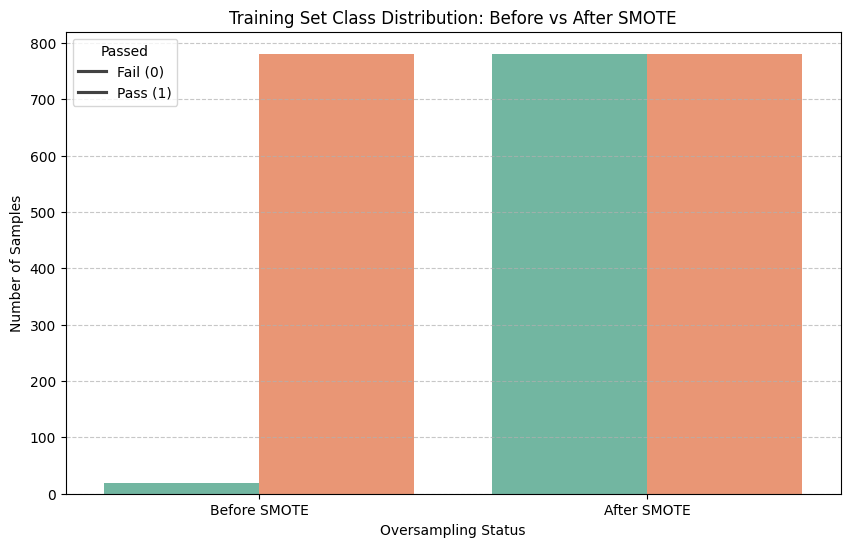

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for visualization
before_smote = pd.Series(y_train_raw).value_counts().reset_index()
before_smote['Status'] = 'Before SMOTE'

after_smote = pd.Series(y_train).value_counts().reset_index()
after_smote['Status'] = 'After SMOTE'

plot_df = pd.concat([before_smote, after_smote])
plot_df.columns = ['passed', 'count', 'Status']

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='Status', y='count', hue='passed', data=plot_df, palette='Set2')
plt.title('Training Set Class Distribution: Before vs After SMOTE')
plt.xlabel('Oversampling Status')
plt.ylabel('Number of Samples')
plt.legend(title='Passed', labels=['Fail (0)', 'Pass (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Percentage of Students who Passed: 97.60%
Percentage of Students who Failed: 2.40%


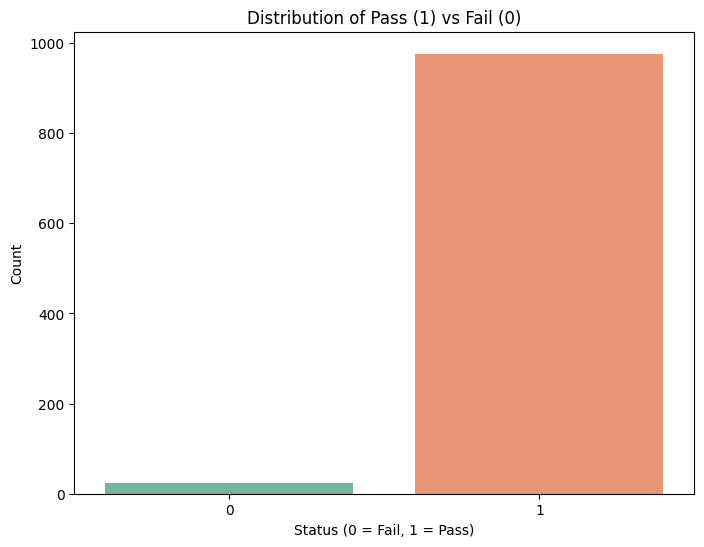

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of the target variable 'passed'
plt.figure(figsize=(8, 6))
sns.countplot(x='passed', hue='passed', data=df, palette='Set2', legend=False)
plt.title('Distribution of Pass (1) vs Fail (0)')
plt.xlabel('Status (0 = Fail, 1 = Pass)')
plt.ylabel('Count')

# Calculate percentages
counts = df['passed'].value_counts(normalize=True) * 100
print(f"Percentage of Students who Passed: {counts[1]:.2f}%")
if 0 in counts:
    print(f"Percentage of Students who Failed: {counts[0]:.2f}%")

plt.show()

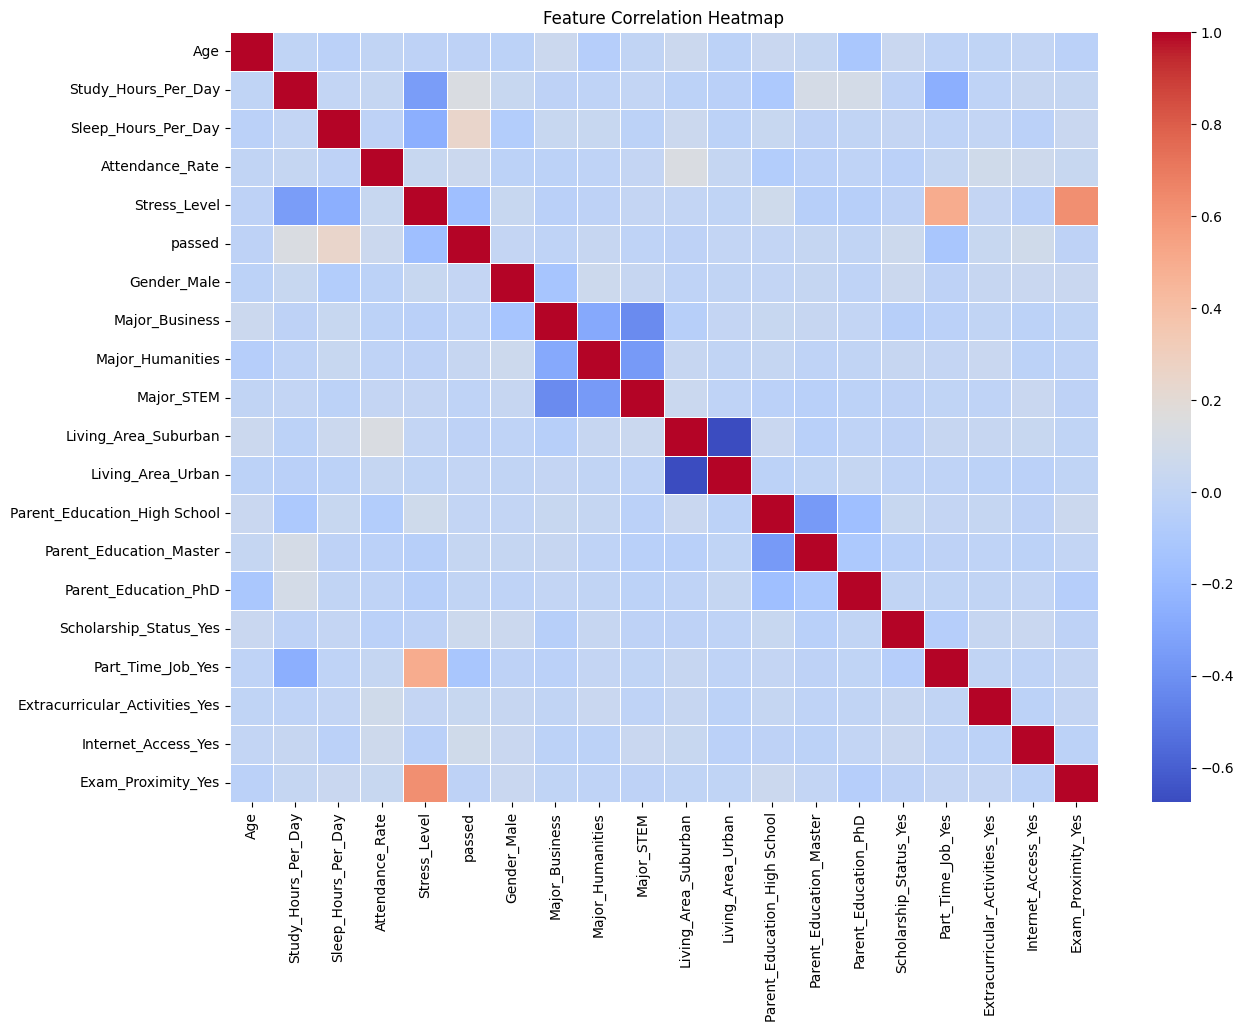

Correlations with the target 'passed':


,passed
passed,1.000000
Sleep_Hours_Per_Day,0.247160
Study_Hours_Per_Day,0.137126
Internet_Access_Yes,0.078308
Scholarship_Status_Yes,0.059810
Attendance_Rate,0.055488
Extracurricular_Activities_Yes,0.033759
Major_Humanities,0.027019
Parent_Education_Master,0.022808
Gender_Male,0.012127


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation matrix for the encoded dataframe
plt.figure(figsize=(14, 10))
correlation_matrix = df_encoded.corr()

# Create the heatmap
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

# Specifically look at correlations with the target variable 'passed'
print("Correlations with the target 'passed':")
display(correlation_matrix['passed'].sort_values(ascending=False))

### 1. Logistic Regression

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np

# Define the model
log_reg = LogisticRegression(random_state=42, solver='liblinear')

# Define the parameter grid for GridSearchCV
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

# Initialize GridSearchCV
grid_search_lr = GridSearchCV(estimator=log_reg, param_grid=param_grid_lr, cv=5, scoring='f1', verbose=1, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search_lr.fit(X_train, y_train)

print("Best parameters for Logistic Regression:", grid_search_lr.best_params_)
print("Best F1-score for Logistic Regression:", grid_search_lr.best_score_)

# Get the best model
best_log_reg = grid_search_lr.best_estimator_

# Make predictions on the test set
y_pred_lr = best_log_reg.predict(X_test)
y_prob_lr = best_log_reg.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)

print(f"\nLogistic Regression Performance on Test Set:")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"F1-Score: {f1_lr:.4f}")
print(f"ROC AUC: {roc_auc_lr:.4f}")
print(f"Confusion Matrix:\n{conf_matrix_lr}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters for Logistic Regression: {'C': 100, 'penalty': 'l2'}
Best F1-score for Logistic Regression: 0.9699206495667922

Logistic Regression Performance on Test Set:
Accuracy: 0.9450
Precision: 0.9792
Recall: 0.9641
F1-Score: 0.9716
ROC AUC: 0.8287
Confusion Matrix:
[[  1   4]
 [  7 188]]


### 2. Random Forest Classifier

In [23]:
from sklearn.ensemble import RandomForestClassifier

# Define the model
rf_clf = RandomForestClassifier(random_state=42)

# Define the parameter grid for GridSearchCV
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Initialize GridSearchCV
grid_search_rf = GridSearchCV(estimator=rf_clf, param_grid=param_grid_rf, cv=5, scoring='f1', verbose=1, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search_rf.fit(X_train, y_train)

print("Best parameters for Random Forest:", grid_search_rf.best_params_)
print("Best F1-score for Random Forest:", grid_search_rf.best_score_)

# Get the best model
best_rf_clf = grid_search_rf.best_estimator_

# Make predictions on the test set
y_pred_rf = best_rf_clf.predict(X_test)
y_prob_rf = best_rf_clf.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

print(f"\nRandom Forest Performance on Test Set:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")
print(f"ROC AUC: {roc_auc_rf:.4f}")
print(f"Confusion Matrix:\n{conf_matrix_rf}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters for Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best F1-score for Random Forest: 0.9903560267238192

Random Forest Performance on Test Set:
Accuracy: 0.9800
Precision: 0.9799
Recall: 1.0000
F1-Score: 0.9898
ROC AUC: 0.9436
Confusion Matrix:
[[  1   4]
 [  0 195]]


### 3. Gradient Boosting Classifier

In [24]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Define the model
gbc_clf = GradientBoostingClassifier(random_state=42)

# Reduced parameter grid to speed up execution
param_grid_gbc = {
    'n_estimators': [100, 300], # Reduced from 4 to 2 options
    'learning_rate': [0.05, 0.1], # Reduced from 4 to 2 options
    'max_depth': [3, 5], # Reduced from 4 to 2 options
    'subsample': [0.8, 1.0] # Kept both options
}

# Using 'recall' as the scoring metric to prioritize finding the minority 'Fail' class
grid_search_gbc = GridSearchCV(estimator=gbc_clf, param_grid=param_grid_gbc, cv=5, scoring='recall', verbose=1, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search_gbc.fit(X_train, y_train)

print("Best parameters for Gradient Boosting Classifier:", grid_search_gbc.best_params_)
print("Best Recall-score for Gradient Boosting Classifier:", grid_search_gbc.best_score_)

# Get the best model
best_gbc_clf = grid_search_gbc.best_estimator_

# Make predictions on the test set
y_pred_gbc = best_gbc_clf.predict(X_test)
y_prob_gbc = best_gbc_clf.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy_gbc = accuracy_score(y_test, y_pred_gbc)
precision_gbc = precision_score(y_test, y_pred_gbc)
recall_gbc = recall_score(y_test, y_pred_gbc)
f1_gbc = f1_score(y_test, y_pred_gbc)
roc_auc_gbc = roc_auc_score(y_test, y_prob_gbc)
conf_matrix_gbc = confusion_matrix(y_test, y_pred_gbc)

print(f"\nGradient Boosting Classifier Performance on Test Set:")
print(f"Accuracy: {accuracy_gbc:.4f}")
print(f"Precision: {precision_gbc:.4f}")
print(f"Recall: {recall_gbc:.4f}")
print(f"F1-Score: {f1_gbc:.4f}")
print(f"ROC AUC: {roc_auc_gbc:.4f}")
print(f"Confusion Matrix:\n{conf_matrix_gbc}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters for Gradient Boosting Classifier: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Best Recall-score for Gradient Boosting Classifier: 0.9859056018291688

Gradient Boosting Classifier Performance on Test Set:
Accuracy: 0.9800
Precision: 0.9948
Recall: 0.9846
F1-Score: 0.9897
ROC AUC: 0.9733
Confusion Matrix:
[[  4   1]
 [  3 192]]


### Experimental Comparison and Analysis

In [25]:
import pandas as pd

results = {
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [accuracy_lr, accuracy_rf, accuracy_gbc],
    'Precision': [precision_lr, precision_rf, precision_gbc],
    'Recall': [recall_lr, recall_rf, recall_gbc],
    'F1-Score': [f1_lr, f1_rf, f1_gbc],
    'ROC AUC': [roc_auc_lr, roc_auc_rf, roc_auc_gbc]
}

results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')

print("\nModel Comparison:")
display(results_df.sort_values(by='F1-Score', ascending=False))


Model Comparison:


,Accuracy,Precision,Recall,F1-Score,ROC AUC
Model,,,,,
Random Forest,0.980,0.979899,1.000000,0.989848,0.943590
Gradient Boosting,0.980,0.994819,0.984615,0.989691,0.973333
Logistic Regression,0.945,0.979167,0.964103,0.971576,0.828718


In [26]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Baseline model: Always predict 'Pass' (1)
y_pred_baseline = np.ones(len(y_test))
# For ROC AUC, a constant prediction usually yields 0.5
y_prob_baseline = np.ones(len(y_test))

# Evaluate Baseline
accuracy_bl = accuracy_score(y_test, y_pred_baseline)
precision_bl = precision_score(y_test, y_pred_baseline)
recall_bl = recall_score(y_test, y_pred_baseline)
f1_bl = f1_score(y_test, y_pred_baseline)
roc_auc_bl = 0.5 # Baseline for a constant classifier

# Add baseline to results
baseline_results = pd.DataFrame({
    'Accuracy': [accuracy_bl],
    'Precision': [precision_bl],
    'Recall': [recall_bl],
    'F1-Score': [f1_bl],
    'ROC AUC': [roc_auc_bl]
}, index=['Baseline (Always Pass)'])

# Update results_df
results_df_with_baseline = pd.concat([results_df, baseline_results])

print("Model Comparison including Baseline:")
display(results_df_with_baseline.sort_values(by='F1-Score', ascending=False))

Model Comparison including Baseline:


,Accuracy,Precision,Recall,F1-Score,ROC AUC
Random Forest,0.980,0.979899,1.000000,0.989848,0.943590
Gradient Boosting,0.980,0.994819,0.984615,0.989691,0.973333
Baseline (Always Pass),0.975,0.975000,1.000000,0.987342,0.500000
Logistic Regression,0.945,0.979167,0.964103,0.971576,0.828718


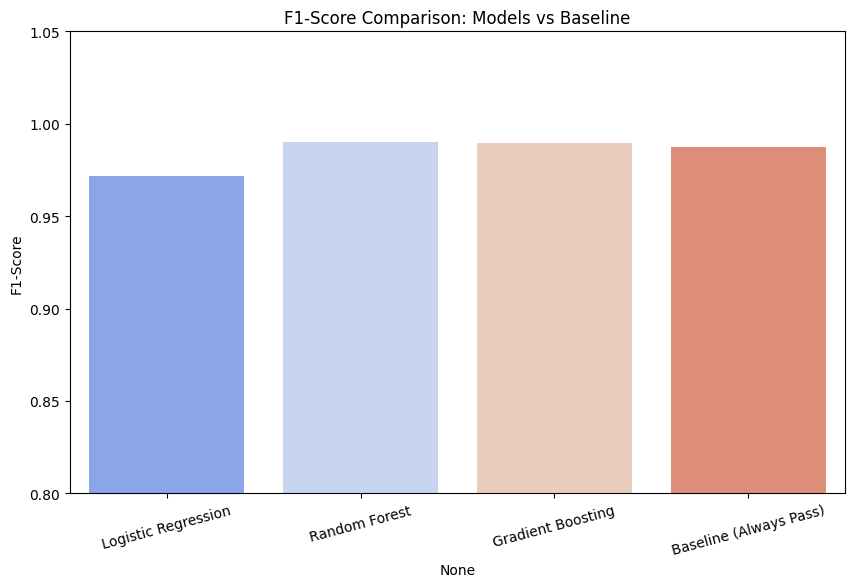

In [27]:
# Re-visualize comparison with baseline
plt.figure(figsize=(10, 6))
sns.barplot(x=results_df_with_baseline.index, y='F1-Score', hue=results_df_with_baseline.index, data=results_df_with_baseline, palette='coolwarm', legend=False)
plt.title('F1-Score Comparison: Models vs Baseline')
plt.ylabel('F1-Score')
plt.ylim(0.8, 1.05)
plt.xticks(rotation=15)
plt.show()

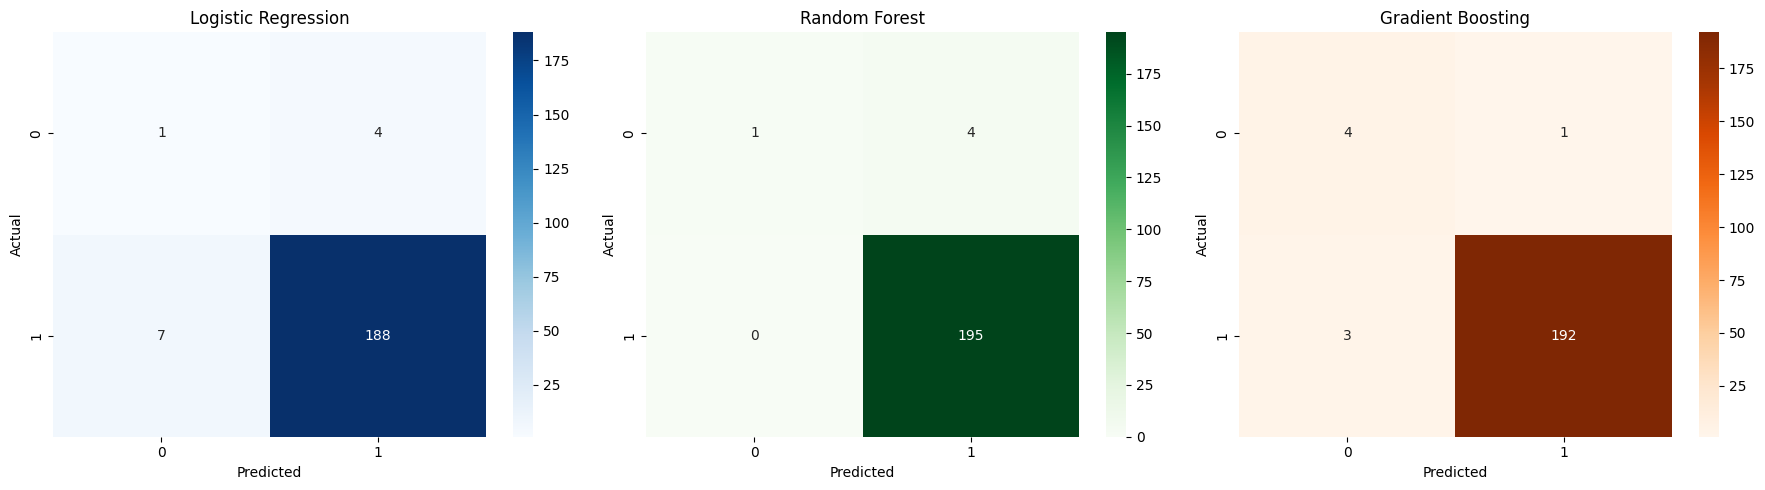

In [28]:
from sklearn.metrics import RocCurveDisplay

# Create a multi-plot figure for confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Logistic Regression Confusion Matrix
sns.heatmap(conf_matrix_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Random Forest Confusion Matrix
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# Gradient Boosting Confusion Matrix
sns.heatmap(conf_matrix_gbc, annot=True, fmt='d', cmap='Oranges', ax=axes[2])
axes[2].set_title('Gradient Boosting')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

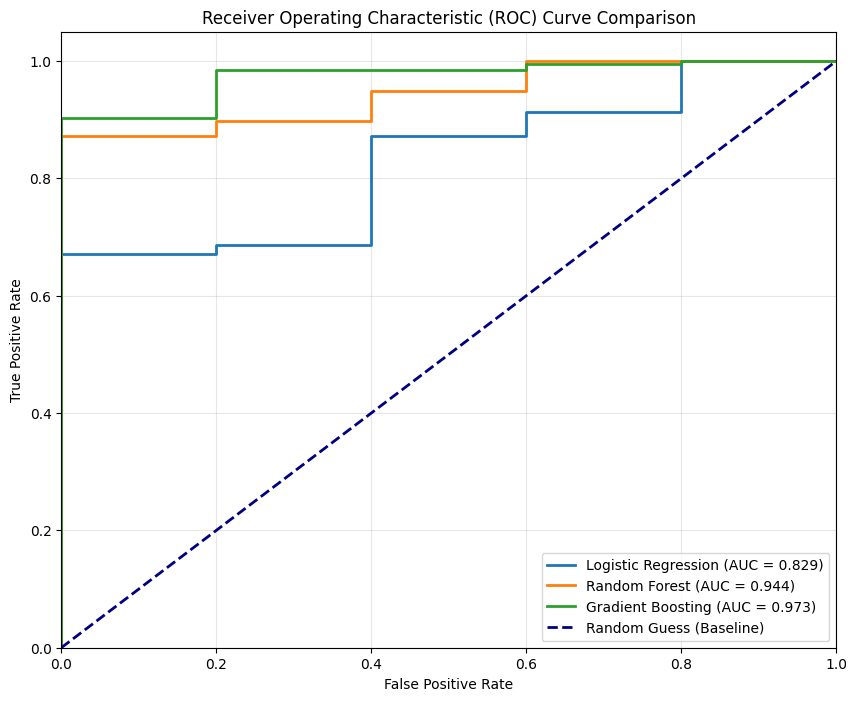

In [29]:
from sklearn.metrics import roc_curve, auc

# Plot ROC Curves for all models
plt.figure(figsize=(10, 8))

models = [
    (y_test, y_prob_lr, 'Logistic Regression'),
    (y_test, y_prob_rf, 'Random Forest'),
    (y_test, y_prob_gbc, 'Gradient Boosting')
]

for y_true, y_prob, label in models:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{label} (AUC = {roc_auc:.3f})')

# Plot Baseline
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (Baseline)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Visualizing Model Performance

/tmp/ipykernel_2465/1763240405.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y='F1-Score', data=results_df, palette='viridis')
/tmp/ipykernel_2465/1763240405.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y='Accuracy', data=results_df, palette='magma')
/tmp/ipykernel_2465/1763240405.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y='ROC AUC', data=results_df, palette='cividis')


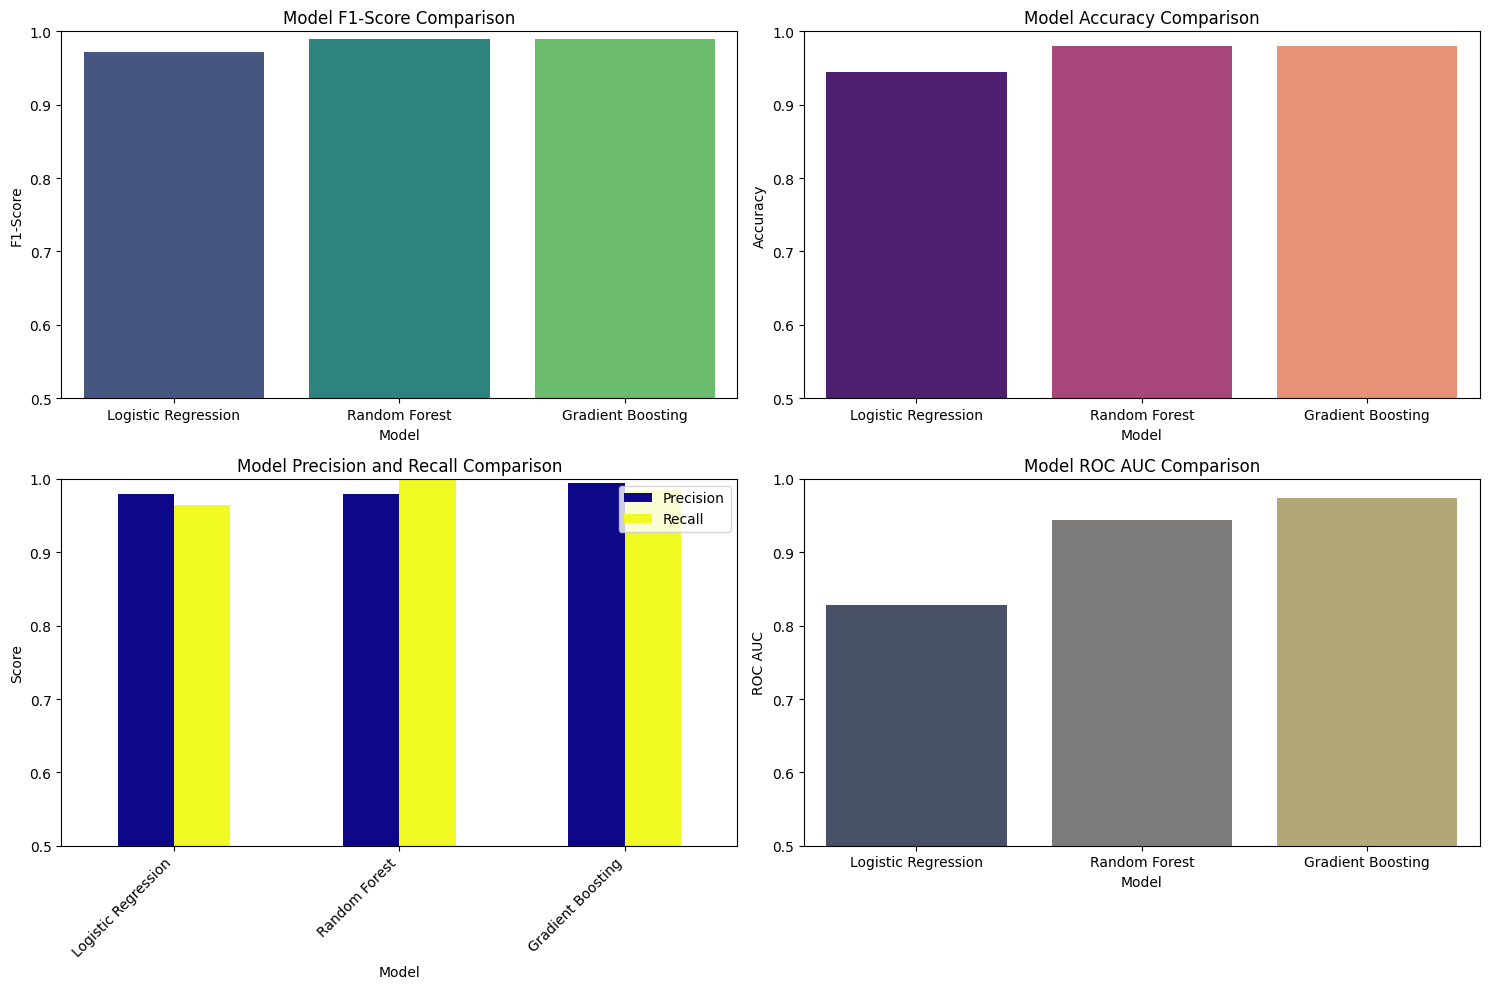

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure for visualizations
plt.figure(figsize=(15, 10))

# Plot F1-Score
plt.subplot(2, 2, 1) # 2 rows, 2 columns, 1st plot
sns.barplot(x=results_df.index, y='F1-Score', data=results_df, palette='viridis')
plt.title('Model F1-Score Comparison')
plt.ylabel('F1-Score')
plt.ylim(0.5, 1.0) # Set a reasonable y-limit for scores

# Plot Accuracy
plt.subplot(2, 2, 2) # 2 rows, 2 columns, 2nd plot
sns.barplot(x=results_df.index, y='Accuracy', data=results_df, palette='magma')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.5, 1.0)

# Plot Precision and Recall
plt.subplot(2, 2, 3) # 2 rows, 2 columns, 3rd plot
results_df[['Precision', 'Recall']].plot(kind='bar', ax=plt.gca(), cmap='plasma')
plt.title('Model Precision and Recall Comparison')
plt.ylabel('Score')
plt.ylim(0.5, 1.0)
plt.xticks(rotation=45, ha='right')

# Plot ROC AUC
plt.subplot(2, 2, 4) # 2 rows, 2 columns, 4th plot
sns.barplot(x=results_df.index, y='ROC AUC', data=results_df, palette='cividis')
plt.title('Model ROC AUC Comparison')
plt.ylabel('ROC AUC')
plt.ylim(0.5, 1.0)

plt.tight_layout()
plt.show()

## Feature Importance Analysis

The best model based on F1-Score is: Random Forest


/tmp/ipykernel_2465/946564355.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.head(20).values, y=feature_importances.head(20).index, palette='viridis')


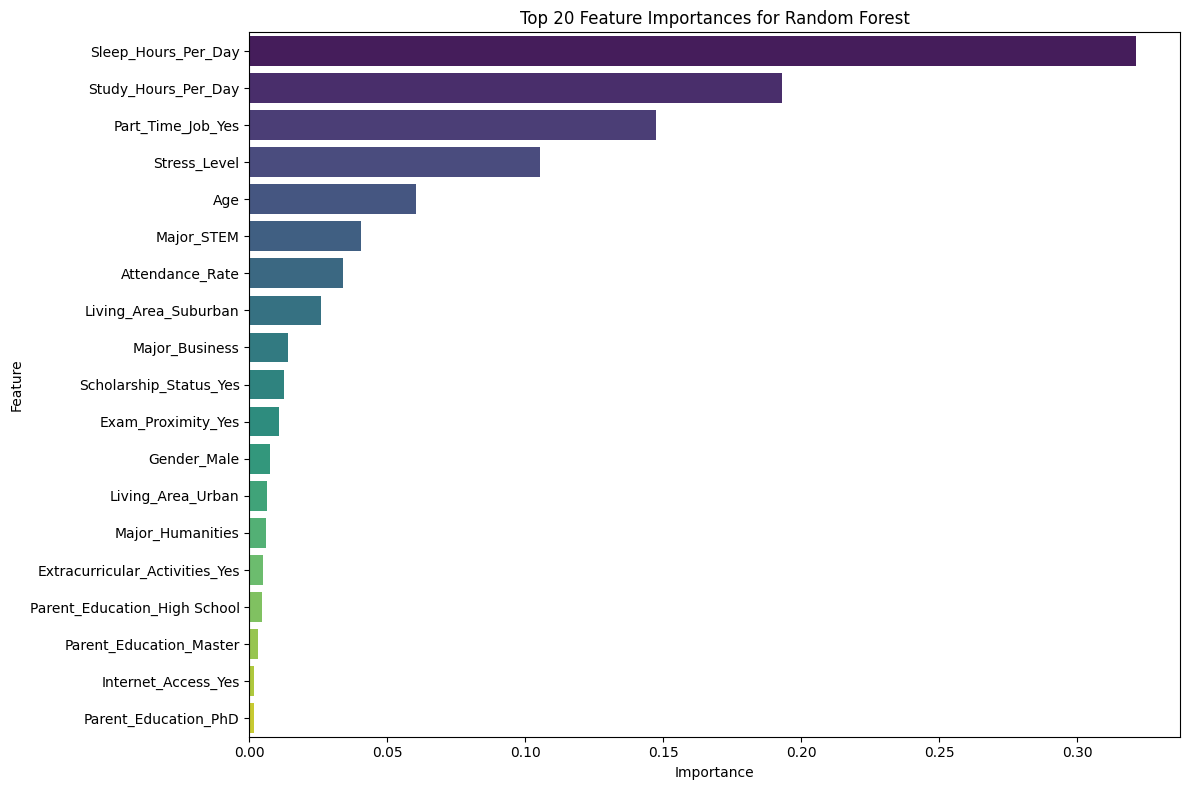

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify the best model based on F1-Score
best_model_name = results_df['F1-Score'].idxmax()
print(f"The best model based on F1-Score is: {best_model_name}")

# Get the best estimator and feature importances
if best_model_name == 'Logistic Regression':
    best_model_estimator = best_log_reg
    # For Logistic Regression, coefficients represent feature importance
    feature_importances = pd.Series(best_model_estimator.coef_[0], index=X_train.columns)
elif best_model_name == 'Random Forest':
    best_model_estimator = best_rf_clf
    feature_importances = pd.Series(best_model_estimator.feature_importances_, index=X_train.columns)
elif best_model_name == 'Gradient Boosting':
    best_model_estimator = best_gbc_clf
    feature_importances = pd.Series(best_model_estimator.feature_importances_, index=X_train.columns)
else:
    print("Unknown best model.")
    feature_importances = pd.Series()

# Sort feature importances
feature_importances = feature_importances.sort_values(ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importances.head(20).values, y=feature_importances.head(20).index, palette='viridis')
plt.title(f'Top 20 Feature Importances for {best_model_name}')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [32]:
from sklearn.metrics import classification_report

print("--- Logistic Regression Classification Report ---")
print(classification_report(y_test, y_pred_lr, target_names=['Fail (0)', 'Pass (1)']))

print("\n--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf, target_names=['Fail (0)', 'Pass (1)']))

print("\n--- Gradient Boosting Classification Report ---")
print(classification_report(y_test, y_pred_gbc, target_names=['Fail (0)', 'Pass (1)']))

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

    Fail (0)       0.12      0.20      0.15         5
    Pass (1)       0.98      0.96      0.97       195

    accuracy                           0.94       200
   macro avg       0.55      0.58      0.56       200
weighted avg       0.96      0.94      0.95       200


--- Random Forest Classification Report ---
              precision    recall  f1-score   support

    Fail (0)       1.00      0.20      0.33         5
    Pass (1)       0.98      1.00      0.99       195

    accuracy                           0.98       200
   macro avg       0.99      0.60      0.66       200
weighted avg       0.98      0.98      0.97       200


--- Gradient Boosting Classification Report ---
              precision    recall  f1-score   support

    Fail (0)       0.57      0.80      0.67         5
    Pass (1)       0.99      0.98      0.99       195

    accuracy                          